In [71]:
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms 

In [72]:
import gc

gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_allocated() / 1024**2, "MB")

629.275390625 MB


In [73]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vgg = models.vgg16(pretrained=True).features #берём без полносвязных слоёв
vgg = vgg.to(DEVICE)
vgg.eval()

for param in vgg.parameters():
    param.requires_grad = False

print(vgg)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [74]:
def load_image(path, max_size = 512):
    image = Image.open(path).convert("RGB") #ТАК КАК ВГГ РАБОТАЕТ В РГБ

    transform = transforms.Compose([
        transforms.Resize(max_size),
        transforms.ToTensor()
    ])

    image = transform(image).unsqueeze(0) #dobav batch 

    return image.to(DEVICE)

content = load_image("style\content.jpg")
style = load_image("style\style5.jpg")

<>:13: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\s'
C:\Users\semen\AppData\Local\Temp\ipykernel_28448\3383301086.py:13: SyntaxWarning: invalid escape sequence '\c'
  content = load_image("style\content.jpg")
C:\Users\semen\AppData\Local\Temp\ipykernel_28448\3383301086.py:14: SyntaxWarning: invalid escape sequence '\s'
  style = load_image("style\style5.jpg")


In [75]:
def get_features(x, model):
    layers = {
        '0': 'conv1_1',
        '5': 'conv2_1',
        '10': 'conv3_1',
        '19': 'conv4_1',
        '28': 'conv5_1'
    }

    features = {}
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
    
    return features

In [76]:
content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

In [77]:
def gram_matrix(tensor):
    _, c, h, w = tensor.size()
    tensor = tensor.view(c, h*w)
    gram = torch.mm(tensor, tensor.t())

    return gram

In [78]:
style_grams = {layer: gram_matrix(style_features[layer])
               for layer in style_features}

In [79]:
target = content.clone().requires_grad_(True).to(DEVICE)
#target = nn.Parameter(content.clone())

optimizer = torch.optim.AdamW([target], lr = 0.01)

content_weight = 1e2
style_weight = 1e6
epoch = 300

In [80]:
style_weights = {
    'conv1_1': 0.3,
    'conv2_1': 0.5,
    'conv3_1': 0.5,
    'conv4_1': 8.8,
    'conv5_1': 10.0
}

In [81]:
total_loss = 0
layer_loss = 0 
content_loss = 0

for i in range(epoch):
    style_loss = 0
    target_features = get_features(target, vgg)

    content_loss = torch.mean( target_features['conv4_1'] - content_features['conv4_1'])**2

    for layer in style_features:
        target_one_feature = target_features[layer]
        target_gram = gram_matrix(target_one_feature)
        style_gram = style_grams[layer]

        _, c, h , w = target_one_feature.shape

        layer_loss = torch.mean((target_gram - style_gram)**2)
        style_loss += style_weights[layer] * layer_loss / (c*h*w)
    
    total_loss = content_weight*content_loss + style_weight*style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    print(f"Step {i}, Loss: {total_loss.item()}")

Step 0, Loss: 28988460.0
Step 1, Loss: 21709558.0
Step 2, Loss: 16818316.0
Step 3, Loss: 12901166.0
Step 4, Loss: 10005564.0
Step 5, Loss: 7956014.0
Step 6, Loss: 6509948.5
Step 7, Loss: 5496988.0
Step 8, Loss: 4789689.0
Step 9, Loss: 4300805.5
Step 10, Loss: 3953544.5
Step 11, Loss: 3690511.5
Step 12, Loss: 3482702.25
Step 13, Loss: 3313936.25
Step 14, Loss: 3170343.5
Step 15, Loss: 3040670.25
Step 16, Loss: 2917413.0
Step 17, Loss: 2797242.0
Step 18, Loss: 2678876.25
Step 19, Loss: 2561736.25
Step 20, Loss: 2447391.0
Step 21, Loss: 2336737.25
Step 22, Loss: 2230605.0
Step 23, Loss: 2129657.5
Step 24, Loss: 2034333.0
Step 25, Loss: 1945102.375
Step 26, Loss: 1862443.125
Step 27, Loss: 1786174.75
Step 28, Loss: 1715844.5
Step 29, Loss: 1651186.875
Step 30, Loss: 1591590.25
Step 31, Loss: 1536797.5
Step 32, Loss: 1486306.75
Step 33, Loss: 1439851.75
Step 34, Loss: 1397008.5
Step 35, Loss: 1357283.25
Step 36, Loss: 1320388.25
Step 37, Loss: 1286156.25
Step 38, Loss: 1254390.5
Step 39, Lo

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7251613..1.3565602].


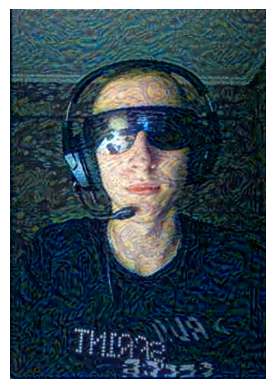

In [82]:
def imshow(tensor):
    image = tensor.clone().detach().cpu().squeeze(0)
    image = image.permute(1, 2, 0)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

imshow(target)